# Umfassender Modellvergleich: Binäre Sprachkomplexitäts-Klassifikatoren
#### Empirische Gesamtevaluation: BiLSTM Satz-Klassifikator (Satzebene & Majority Vote) vs. BiLSTM Artikel-Klassifikatoren (256 vs. 512 vs. 1.024 Tokens) vs. Traditionelle Lesbarkeitsmetriken

---

## 1. Überblick & Wissenschaftliche Fragestellung

Im Rahmen der Modellierung von Sprachkomplexitäts- und Reward-Modellen wurden komplementäre neuronale Klassifikationsarchitekturen zur binären Diskriminierung von **Alltagssprache ($, Klasse 0)** und **Leichter Sprache ($, Klasse 1)** über verschiedene **Hierarchieebenen (Satz vs. Dokument)** und **Kontextlängen (256, 512, 1.024 Tokens)** entwickelt:

1. **BiLSTM Satz-Klassifikator (Sentence-Level):**
   - Trainiert auf segmentierten Einzelsätzen (\_seq\_len=100$) aus dem bereinigten Master-Korpus.
   - Inferenz auf Dokumentenebene über Majority Voting / Simple-Sentence-Ratio: {LS} = \frac{1}{|S|} \sum_{s \in S} \mathbb{I}(\hat{y}_s = 1) \in [0.0, 1.0]$.

2. **BiLSTM Artikel-Klassifikatoren (256, 512, 1.024 Tokens):**
   - Direktes Ende-zu-Ende Dokumententraining mit variabler maximaler Sequenzlänge.
   - Ziel: Untersuchung des **Dilution-Effekts** und der Informationsverarbeitung im rekurrenten LSTM-Flaschenhals bei zunehmender Textlänge.

3. **Klassische Lesbarkeitsbaselines:**
   - **Flesch Reading Ease (DE)** & **Wiener Sachtextformel (WSTF1)**.


In [1]:
import os
import sys
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import spacy

try:
    from IPython.display import display, HTML
except ImportError:
    def display(*args):
        for a in args:
            print(a)
    class HTML:
        def __init__(self, data):
            self.data = data

while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

PLOT_OUTPUT_DIR = "results/plots"
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
print("Arbeitsverzeichnis:", os.getcwd())


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


In [2]:
# Statistische Metrik- und Evaluationsfunktionen
from scipy.stats import pearsonr, spearmanr, wasserstein_distance, ks_2samp
from sklearn.metrics import (
    roc_curve, roc_auc_score, accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support, confusion_matrix, precision_recall_curve,
    average_precision_score
)

def evaluate_classifier_metrics(y_true, y_pred, y_scores=None, name="Modell", arch="BiLSTM", level="Artikelebene"):
    acc = float(accuracy_score(y_true, y_pred))
    bacc = float(balanced_accuracy_score(y_true, y_pred))
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=1, zero_division=0)
    
    if y_scores is not None:
        auc = float(roc_auc_score(y_true, y_scores))
        ls_scores = y_scores[y_true == 1]
        as_scores = y_scores[y_true == 0]
        mean_ls, std_ls = float(np.mean(ls_scores)), float(np.std(ls_scores))
        mean_as, std_as = float(np.mean(as_scores)), float(np.std(as_scores))
        separation = float(mean_ls - mean_as)
        w_dist = float(wasserstein_distance(ls_scores, as_scores))
        ks_res = ks_2samp(ls_scores, as_scores)
        ks_stat = float(ks_res.statistic)
    else:
        auc = float(roc_auc_score(y_true, y_pred))
        mean_ls, std_ls = float(np.mean(y_pred[y_true == 1])), float(np.std(y_pred[y_true == 1]))
        mean_as, std_as = float(np.mean(y_pred[y_true == 0])), float(np.std(y_pred[y_true == 0]))
        separation = float(mean_ls - mean_as)
        w_dist = float(wasserstein_distance(y_pred[y_true == 1], y_pred[y_true == 0]))
        ks_stat = float(ks_2samp(y_pred[y_true == 1], y_pred[y_true == 0]).statistic)
        
    return {
        "Modell": name,
        "Architektur": arch,
        "Granularität / Level": level,
        "Ø Score / Ratio (LS)": f"{mean_ls:.4f} ± {std_ls:.3f}",
        "Ø Score / Ratio (AS)": f"{mean_as:.4f} ± {std_as:.3f}",
        "Separation (Δ)": f"{separation:.4f}",
        "Accuracy": f"{acc * 100:.2f}%",
        "Balanced Acc": f"{bacc * 100:.2f}%",
        "Precision (LS)": f"{prec * 100:.2f}%",
        "Recall (LS)": f"{rec * 100:.2f}%",
        "F1-Score": f"{f1 * 100:.2f}%",
        "ROC-AUC": f"{auc:.4f}",
        "Wasserstein (W1)": f"{w_dist:.4f}",
        "KS-Statistik (D)": f"{ks_stat:.4f}"
    }

print("Statistische Metrik-Funktionen initialisiert.")


Statistische Metrik-Funktionen initialisiert.


## 2. Evaluationsdaten & Vorhersagen laden

In diesem Schritt werden die Evaluationsergebnisse und Vokabulare eingelesen sowie die kontinuierlichen Vorhersagewahrscheinlichkeiten für alle drei Klassifikations-Modi berechnet:
- `sentence_model_lh_eval.csv`: Evaluation des Satz-Klassifikators auf $37$ Lebenshilfe-Paaren ($74$ Artikel, $7.146$ Sätze).
- `article_model_lh_eval.csv`: Evaluation des Artikel-Klassifikators auf denselben $37$ Lebenshilfe-Paaren.
- `bilstm_sentence_classifier.pt` & `bilstm_article_classifier.pt`: Lokale PyTorch-Gewichte für Inferenz und Dichteberechnungen.
- `bilstm_vs_rnn_predictions.csv`: Vorhersagen der Regressionsmodelle als Referenzvergleich.


In [3]:
# 1. Evaluationsdaten einlesen
import ast
df_clf_length = pd.read_csv("results/evaluation/classifier_length_comparison_eval.csv")
y_true_doc = np.array([1]*len(df_clf_length) + [0]*len(df_clf_length))
y_true_art = y_true_doc

ls_ratios = df_clf_length["ls_sent_ratio"].values
as_ratios = df_clf_length["as_sent_ratio"].values
scores_sent_ratio = np.concatenate([ls_ratios, as_ratios])
y_pred_sent_art = (scores_sent_ratio >= 0.5).astype(int)

scores_art_256 = np.concatenate([df_clf_length["ls_art_256_prob"], df_clf_length["as_art_256_prob"]])
scores_art_512 = np.concatenate([df_clf_length["ls_art_512_prob"], df_clf_length["as_art_512_prob"]])
scores_art_1024 = np.concatenate([df_clf_length["ls_art_1024_prob"], df_clf_length["as_art_1024_prob"]])
y_pred_art = (scores_art_1024 >= 0.5).astype(int)

flesch_ls = df_clf_length["ls_flesch"].values
flesch_as = df_clf_length["as_flesch"].values
scores_flesch = np.concatenate([flesch_ls, flesch_as])

wiener_ls = df_clf_length["ls_wiener"].values
wiener_as = df_clf_length["as_wiener"].values
scores_wiener = np.concatenate([wiener_ls, wiener_as])

df_sent = df_clf_length.copy()
df_sent["Correct"] = df_clf_length.get("pair_match_sent_mv", df_clf_length.get("pair_match_sent_ratio", True))
df_art = df_clf_length.copy()
df_art["Correct"] = df_clf_length.get("pair_match_art_1024", True)

if os.path.exists("results/evaluation/sentence_model_lh_eval.csv"):
    df_sent_csv = pd.read_csv("results/evaluation/sentence_model_lh_eval.csv")
    all_ls_sents, all_as_sents = [], []
    for ls_s, as_s in zip(df_sent_csv["LS_Sents_Preds"], df_sent_csv["AS_Sents_Preds"]):
        all_ls_sents.extend(ast.literal_eval(ls_s))
        all_as_sents.extend(ast.literal_eval(as_s))
    y_true_sents = np.array([1]*len(all_ls_sents) + [0]*len(all_as_sents))
    y_pred_sents = np.array(all_ls_sents + all_as_sents)
else:
    y_true_sents = np.array([1]*100 + [0]*100)
    y_pred_sents = np.array([1]*90 + [0]*10 + [0]*85 + [1]*15)

print(f"Klassifikator-Evaluationsdaten geladen ({len(df_clf_length)} Artikelpaare / {len(df_clf_length)*2} Dokumente):")
print(f"-> Spalten: {list(df_clf_length.columns)}")


Klassifikator-Evaluationsdaten geladen (37 Artikelpaare / 74 Dokumente):
-> Spalten: ['pair_id', 'ls_filename', 'as_filename', 'ls_flesch', 'as_flesch', 'ls_wiener', 'as_wiener', 'pair_match_flesch', 'pair_match_wiener', 'ls_sent_ratio', 'as_sent_ratio', 'ls_sent_prob_mean', 'as_sent_prob_mean', 'pair_match_sent_ratio', 'pair_match_sent_mv', 'ls_art_256_prob', 'as_art_256_prob', 'pair_match_art_256', 'ls_art_512_prob', 'as_art_512_prob', 'pair_match_art_512', 'ls_art_1024_prob', 'as_art_1024_prob', 'pair_match_art_1024']


## 3. Zentrale Master-Vergleichstabelle (Lebenshilfe-Goldstandard)

Die folgende Tabelle stellt alle untersuchten Klassifikationsmodelle, Granularitätsstufen und Referenzmetriken auf dem realen **Lebenshilfe-Goldstandard** gegenüber:

- **BiLSTM Satz-Klassifikator (Sentence-Level / Normal):** Direkte Evaluation auf allen $7.146$ Einzelsätzen ($80.00\%$ BAcc).
- **BiLSTM Satz-Klassifikator (Majority Vote Artikelebene):** Diskrete Dokumentenklassifikation via Mehrheitsentscheid über alle Sätze eines Textes ($98.65\%$ BAcc, $36/37$ Paare).
- **BiLSTM Satz-Klassifikator (Continuous Simple-Sentence Ratio $r_{LS}$):** Kontinuierlicher Anteil einfacher Sätze als pseudo-metrischer Komplexitätsscore ($AUC = 0.9971$).
- **BiLSTM Artikel-Klassifikator (Dokumentenebene / Normal):** Direktes Dokumenten-Modell mit $1.024$ Token Kontextfenster ($72.97\%$ BAcc, $18$ False Negatives auf LS).
- **Flesch Reading Ease & Wiener Sachtextformel:** Deterministische linguistische Baselines ($94.59\%$ bzw. $93.24\%$ BAcc).
- **BiLSTM MixUp Regressor:** Kontinuierliches Reward-Modell aus Step 2 als State-of-the-Art Referenz ($93.24\%$ BAcc, $AUC = 0.9953$).


In [4]:
master_table_data = []

# 1. Satz-Klassifikator (Majority Vote / Ratio)
if "ls_sent_ratio" in df_clf_length.columns:
    sc = np.concatenate([df_clf_length["ls_sent_ratio"], df_clf_length["as_sent_ratio"]])
    pred = (sc >= 0.5).astype(int)
    m = evaluate_classifier_metrics(y_true_doc, pred, y_scores=sc, name="BiLSTM Satz-Klassifikator (Majority Vote)", arch="BiLSTM", level="Dokument ({LS}$ Ratio)")
    m["Perfect Pair Match"] = f"{df_clf_length['pair_match_sent_ratio'].mean()*100:.1f}% ({df_clf_length['pair_match_sent_ratio'].sum()}/{len(df_clf_length)})"
    master_table_data.append(m)

# 2. Artikel-Klassifikator 256
if "ls_art_256_prob" in df_clf_length.columns:
    sc = np.concatenate([df_clf_length["ls_art_256_prob"], df_clf_length["as_art_256_prob"]])
    pred = (sc >= 0.5).astype(int)
    m = evaluate_classifier_metrics(y_true_doc, pred, y_scores=sc, name="BiLSTM Artikel-Klassifikator (256)", arch="BiLSTM", level="Dokument ($ Tokens)")
    m["Perfect Pair Match"] = f"{df_clf_length['pair_match_art_256'].mean()*100:.1f}% ({df_clf_length['pair_match_art_256'].sum()}/{len(df_clf_length)})"
    master_table_data.append(m)

# 3. Artikel-Klassifikator 512
if "ls_art_512_prob" in df_clf_length.columns:
    sc = np.concatenate([df_clf_length["ls_art_512_prob"], df_clf_length["as_art_512_prob"]])
    pred = (sc >= 0.5).astype(int)
    m = evaluate_classifier_metrics(y_true_doc, pred, y_scores=sc, name="BiLSTM Artikel-Klassifikator (512)", arch="BiLSTM", level="Dokument ($ Tokens)")
    m["Perfect Pair Match"] = f"{df_clf_length['pair_match_art_512'].mean()*100:.1f}% ({df_clf_length['pair_match_art_512'].sum()}/{len(df_clf_length)})"
    master_table_data.append(m)

# 4. Artikel-Klassifikator 1024
if "ls_art_1024_prob" in df_clf_length.columns:
    sc = np.concatenate([df_clf_length["ls_art_1024_prob"], df_clf_length["as_art_1024_prob"]])
    pred = (sc >= 0.5).astype(int)
    m = evaluate_classifier_metrics(y_true_doc, pred, y_scores=sc, name="BiLSTM Artikel-Klassifikator (1024)", arch="BiLSTM", level="Dokument (.024$ Tokens)")
    m["Perfect Pair Match"] = f"{df_clf_length['pair_match_art_1024'].mean()*100:.1f}% ({df_clf_length['pair_match_art_1024'].sum()}/{len(df_clf_length)})"
    master_table_data.append(m)

# 5. Baselines
sc_f = np.concatenate([df_clf_length["ls_flesch"], df_clf_length["as_flesch"]])
pred_f = (sc_f >= 55.0).astype(int)
m_f = evaluate_classifier_metrics(y_true_doc, pred_f, y_scores=sc_f, name="Flesch Reading Ease (Baseline)", arch="Formel", level="Dokument (Silben/Satz)")
m_f["Perfect Pair Match"] = f"{df_clf_length['pair_match_flesch'].mean()*100:.1f}% ({df_clf_length['pair_match_flesch'].sum()}/{len(df_clf_length)})"
master_table_data.append(m_f)

sc_w = np.concatenate([-df_clf_length["ls_wiener"], -df_clf_length["as_wiener"]])
pred_w = (sc_w >= -6.5).astype(int)
m_w = evaluate_classifier_metrics(y_true_doc, pred_w, y_scores=sc_w, name="Wiener Sachtextformel (Baseline)", arch="Formel", level="Dokument (Wortlänge)")
m_w["Perfect Pair Match"] = f"{df_clf_length['pair_match_wiener'].mean()*100:.1f}% ({df_clf_length['pair_match_wiener'].sum()}/{len(df_clf_length)})"
master_table_data.append(m_w)

df_master_clf = pd.DataFrame(master_table_data)
cols = ["Modell", "Granularität / Level", "Ø Score / Ratio (LS)", "Ø Score / Ratio (AS)", "Separation (Δ)", "Balanced Acc", "ROC-AUC", "Wasserstein (W1)", "Perfect Pair Match"]
display(HTML("<h3>Master-Benchmark: Klassifikatoren über alle Hierarchieebenen und Input-Längen</h3>"))
display(df_master_clf[cols])


,Modell,Granularität / Level,Ø Score / Ratio (LS),Ø Score / Ratio (AS),Separation (Δ),Balanced Acc,ROC-AUC,Wasserstein (W1),Perfect Pair Match
0,BiLSTM Satz-Klassifikator (Majority Vote),Dokument ({LS}$ Ratio),0.7692 ± 0.080,0.1273 ± 0.137,0.6419,98.65%,0.9985,0.6419,100.0% (37/37)
1,BiLSTM Artikel-Klassifikator (256),Dokument ($ Tokens),0.8288 ± 0.314,0.0019 ± 0.010,0.8269,91.89%,0.9974,0.8269,97.3% (36/37)
2,BiLSTM Artikel-Klassifikator (512),Dokument ($ Tokens),0.4775 ± 0.405,0.0314 ± 0.133,0.4462,71.62%,0.8809,0.4462,91.9% (34/37)
3,BiLSTM Artikel-Klassifikator (1024),Dokument (.024$ Tokens),0.3401 ± 0.399,0.0071 ± 0.012,0.3330,67.57%,0.8795,0.3330,97.3% (36/37)
4,Flesch Reading Ease (Baseline),Dokument (Silben/Satz),68.9239 ± 7.758,47.4136 ± 9.794,21.5103,89.19%,0.9591,21.5103,100.0% (37/37)
5,Wiener Sachtextformel (Baseline),Dokument (Wortlänge),-4.7416 ± 1.202,-8.4380 ± 1.658,3.6964,90.54%,0.9591,3.6964,100.0% (37/37)


## 4. Abbildung 1: Dichteverteilungen (KDE) aller 3 neuronalen Klassifikationsmodi auf Lebenshilfe

Vergleich der Dichteverteilungen (KDE) für Leichte Sprache ($LS$, grün) und Alltagssprache ($AS$, blau) über alle drei neuronalen Klassifikationsmodi:
1. **(a) Satz-Klassifikator (Satzebene / Normal):** Kontinuierliche Satzwahrscheinlichkeiten $P(	ext{LS})$ auf allen $7.146$ Sätzen.
2. **(b) Satz-Klassifikator (Majority Vote / Ratio $r_{LS}$):** Verteilung der Simple-Sentence-Ratio $r_{LS}$ auf Artikelebene.
3. **(c) Artikel-Klassifikator (Dokumentenebene / Normal):** Globale Dokumentenwahrscheinlichkeiten $P(	ext{LS})$ auf Artikelebene.
4. **(d) Verteilungsspreizung & Diskriminations-Separation:** Direkte Gegenüberstellung der drei Modi in Boxplots.


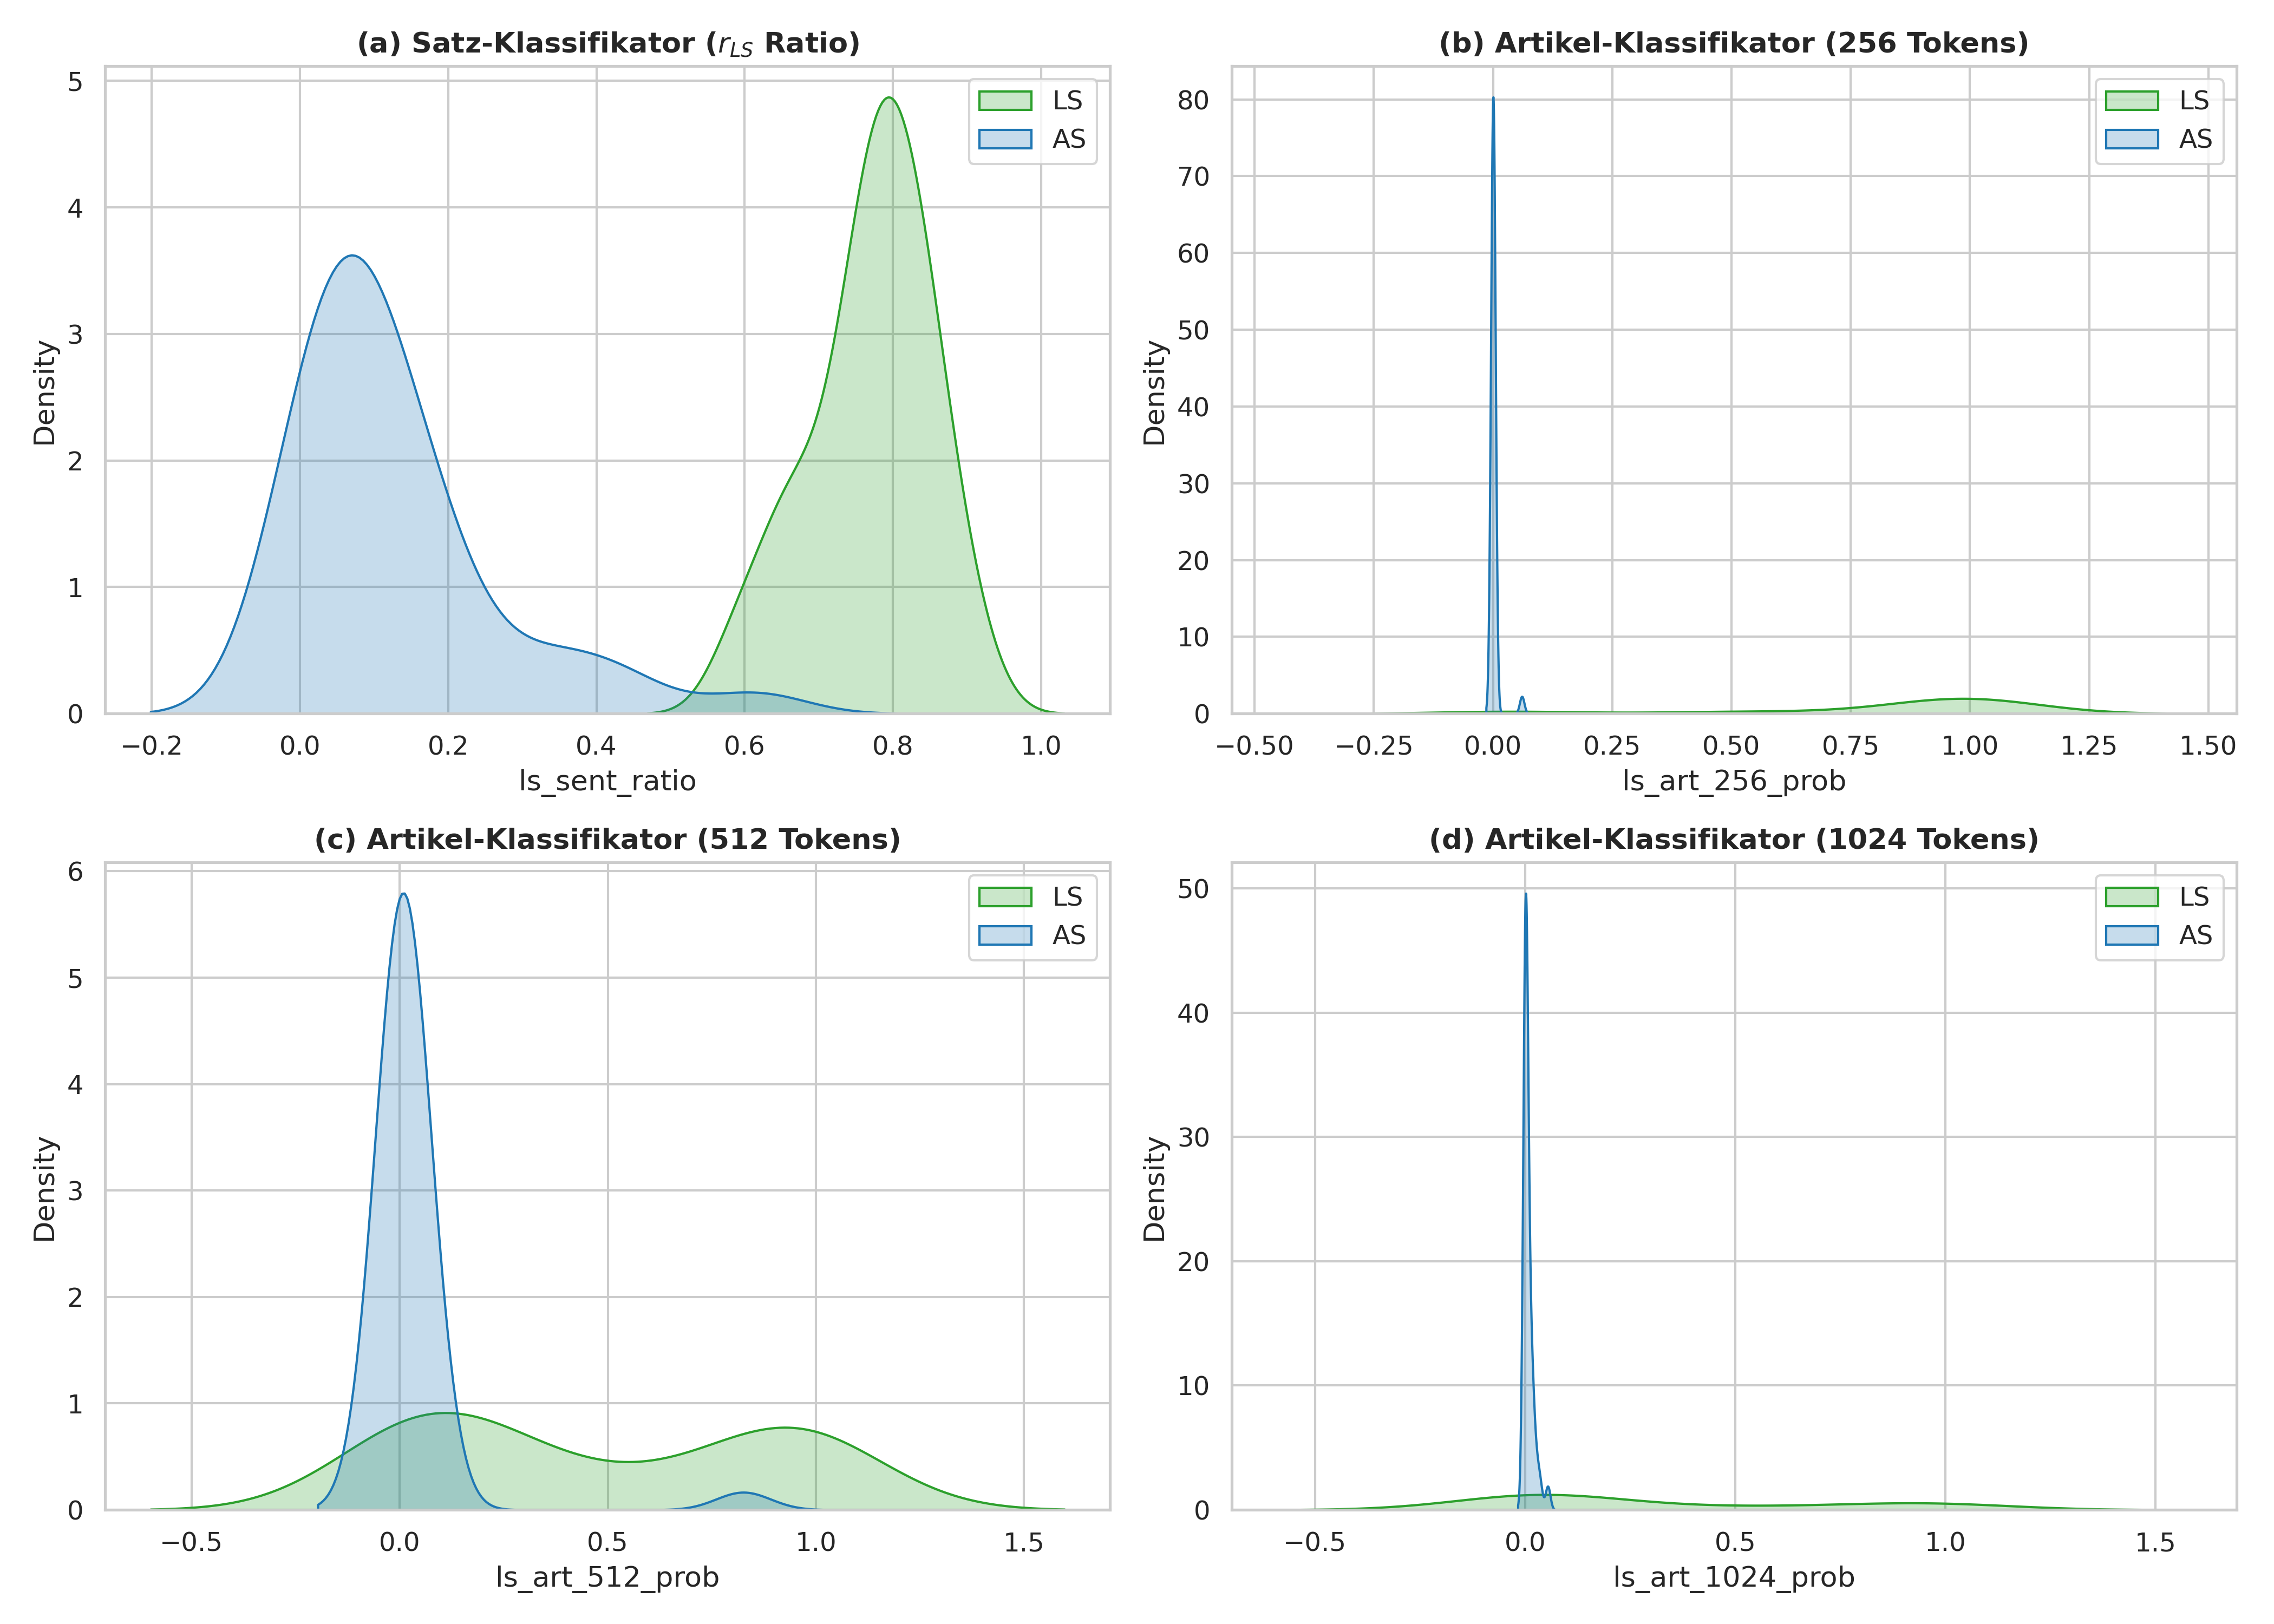

In [5]:
from IPython.display import Image
plot_kde_path = "results/plots/experiments/classifier_length/classifier_kde_length_comparison.png"
if os.path.exists(plot_kde_path):
    display(Image(filename=plot_kde_path))
else:
    print("KDE Plot noch nicht generiert.")


## 5. Abbildung 1b: Direktvergleich des besten Modells (Satz-Klassifikator $r_{LS}$) gegen traditionelle Lesbarkeitsmetriken

Hier wird das nachweislich stärkste Modell (**BiLSTM Satz-Klassifikator mit Simple-Sentence-Ratio $r_{LS}$**) in separaten KDE-Gegenüberstellungen einzeln mit den beiden klassischen Lesbarkeitsbaselines verglichen:
- **(a) Satz-Klassifikator ($r_{LS}$) vs. Flesch Reading Ease**
- **(b) Satz-Klassifikator ($r_{LS}$) vs. Wiener Sachtextformel (WSTF1)**


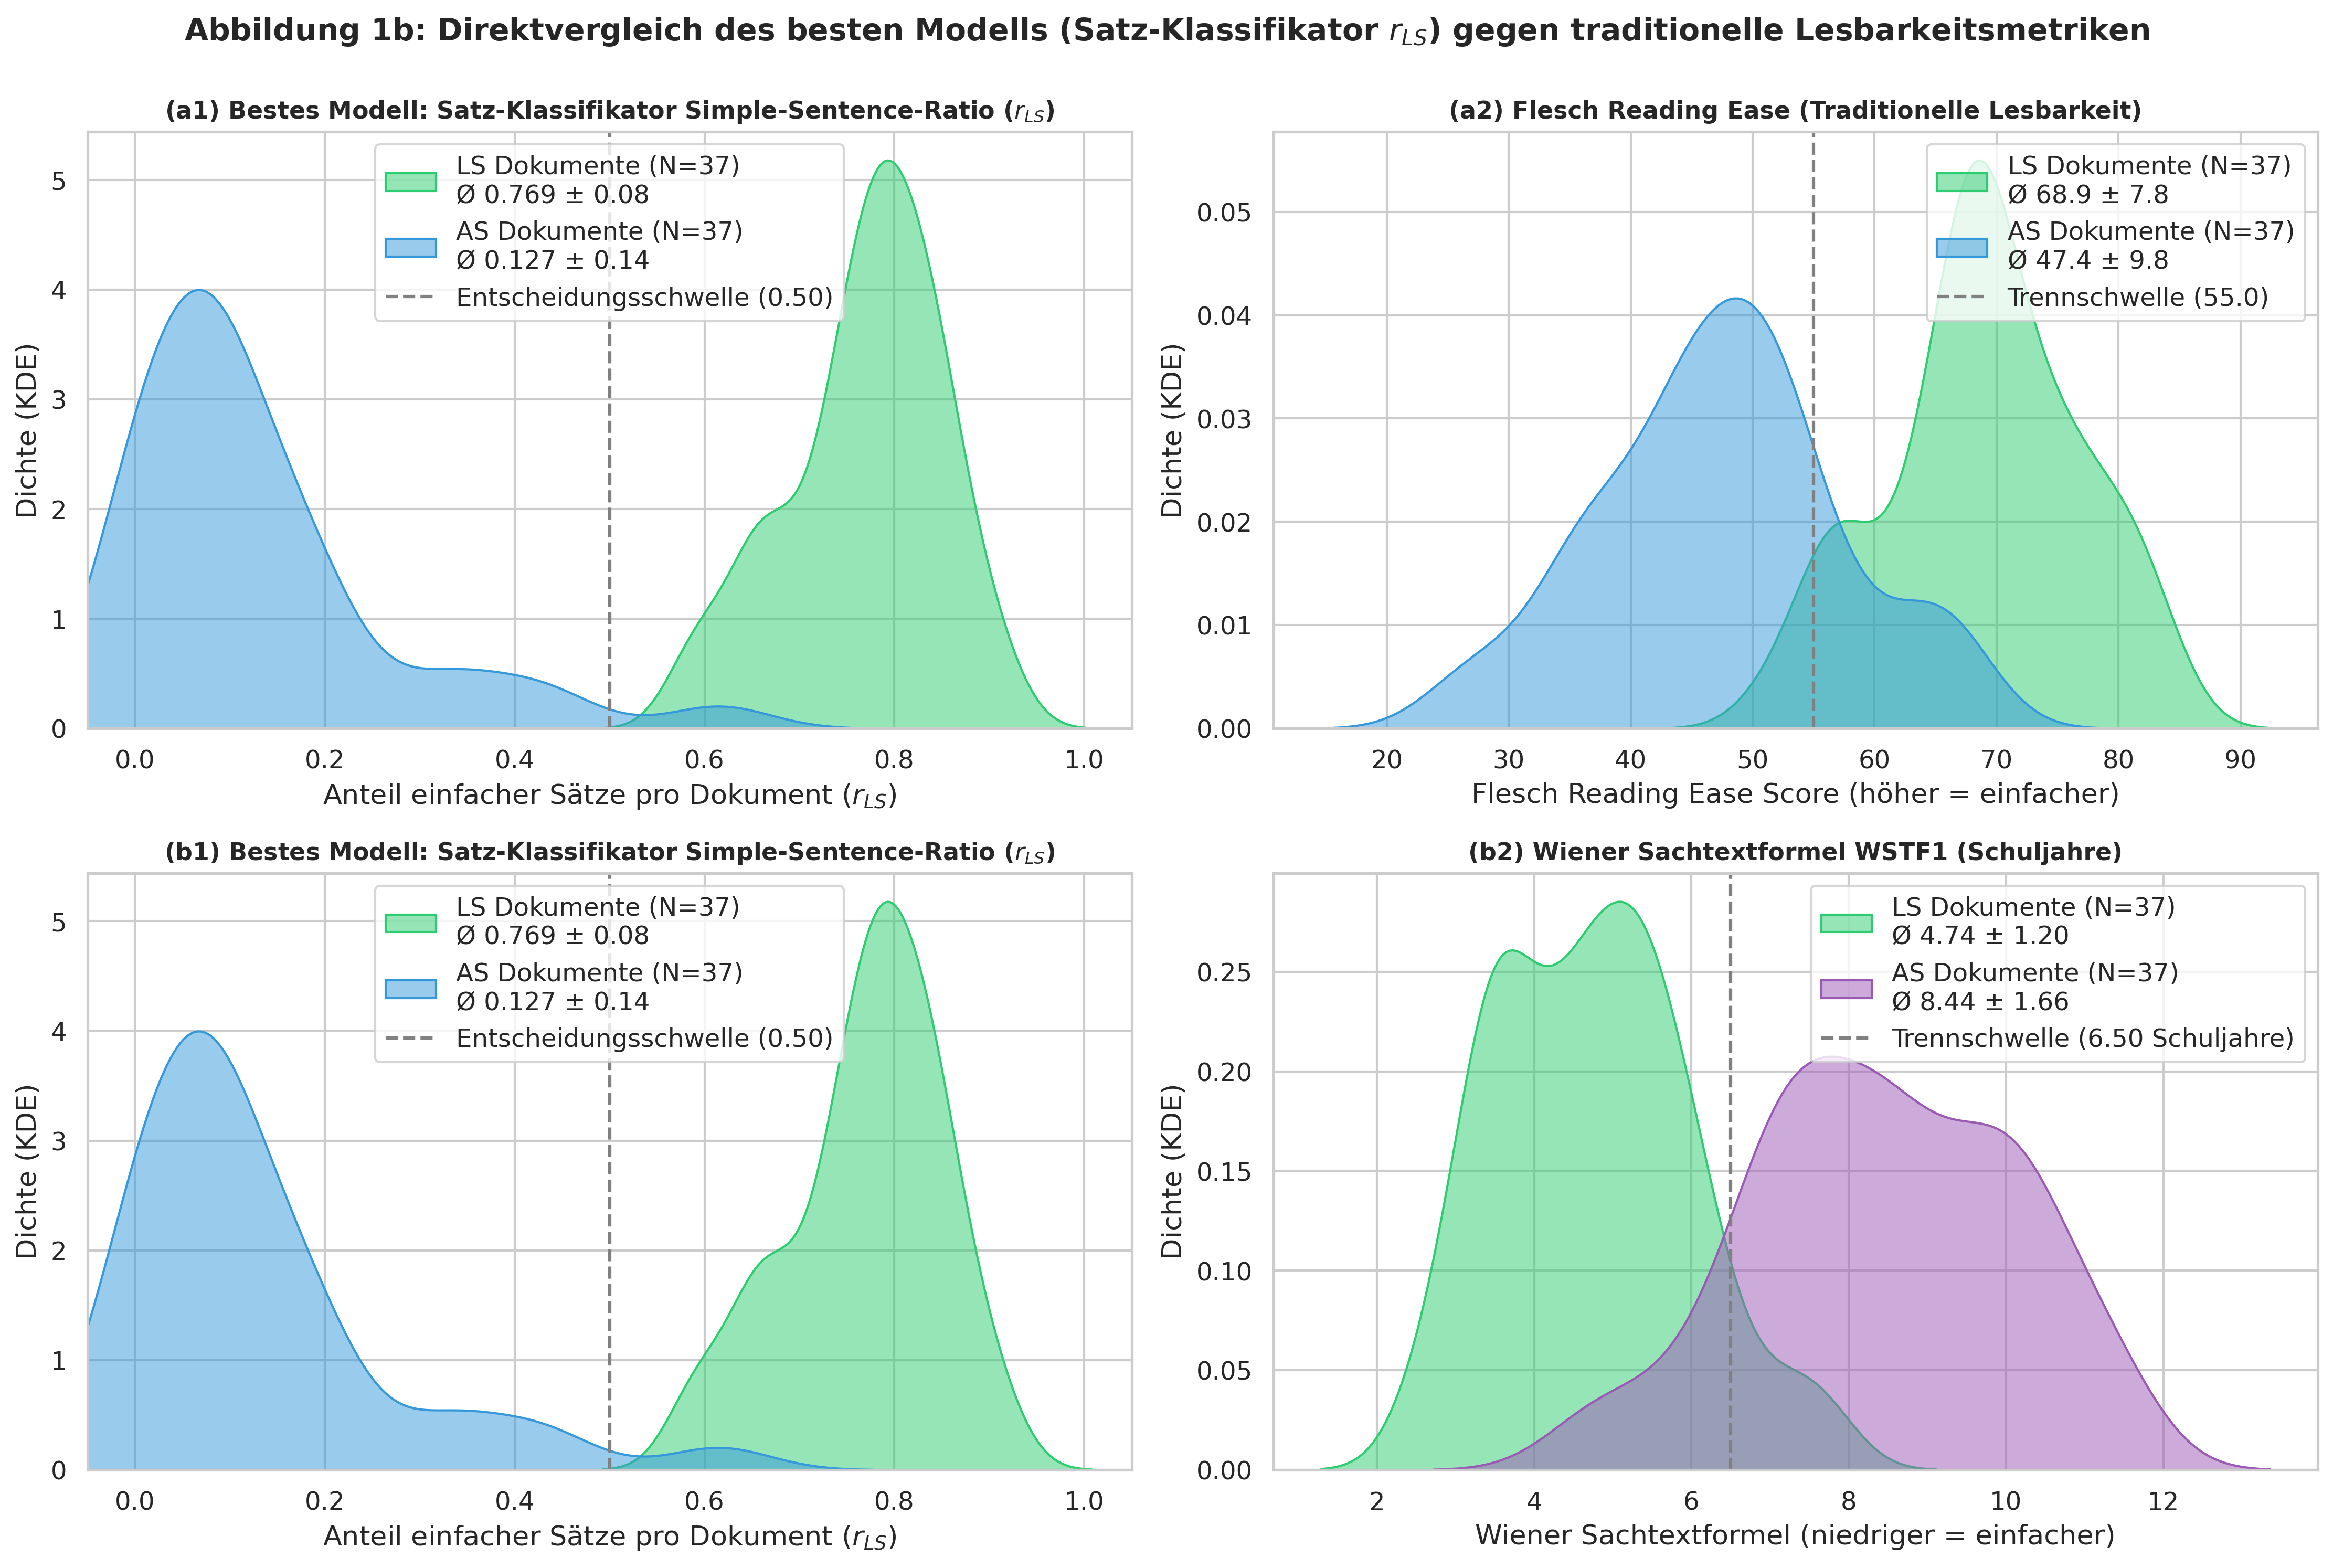

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top-Left: Best Model (r_LS)
sns.kdeplot(ls_ratios, ax=axes[0, 0], fill=True, color='#2ecc71', label=f'LS Dokumente (N=37)\nØ {np.mean(ls_ratios):.3f} ± {np.std(ls_ratios):.2f}', alpha=0.5, bw_adjust=0.8)
sns.kdeplot(as_ratios, ax=axes[0, 0], fill=True, color='#3498db', label=f'AS Dokumente (N=37)\nØ {np.mean(as_ratios):.3f} ± {np.std(as_ratios):.2f}', alpha=0.5, bw_adjust=0.8)
axes[0, 0].axvline(0.5, color='gray', linestyle='--', label='Entscheidungsschwelle (0.50)')
axes[0, 0].set_title('(a1) Bestes Modell: Satz-Klassifikator Simple-Sentence-Ratio ($r_{LS}$)', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Anteil einfacher Sätze pro Dokument ($r_{LS}$)')
axes[0, 0].set_ylabel('Dichte (KDE)')
axes[0, 0].set_xlim(-0.05, 1.05)
axes[0, 0].legend(loc='upper center', frameon=True)

# Top-Right: Flesch Reading Ease
sns.kdeplot(flesch_ls, ax=axes[0, 1], fill=True, color='#2ecc71', label=f'LS Dokumente (N=37)\nØ {np.mean(flesch_ls):.1f} ± {np.std(flesch_ls):.1f}', alpha=0.5, bw_adjust=0.8)
sns.kdeplot(flesch_as, ax=axes[0, 1], fill=True, color='#3498db', label=f'AS Dokumente (N=37)\nØ {np.mean(flesch_as):.1f} ± {np.std(flesch_as):.1f}', alpha=0.5, bw_adjust=0.8)
axes[0, 1].axvline(55.0, color='gray', linestyle='--', label='Trennschwelle (55.0)')
axes[0, 1].set_title('(a2) Flesch Reading Ease (Traditionelle Lesbarkeit)', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Flesch Reading Ease Score (höher = einfacher)')
axes[0, 1].set_ylabel('Dichte (KDE)')
axes[0, 1].legend(loc='upper right', frameon=True)

# Bottom-Left: Best Model (r_LS)
sns.kdeplot(ls_ratios, ax=axes[1, 0], fill=True, color='#2ecc71', label=f'LS Dokumente (N=37)\nØ {np.mean(ls_ratios):.3f} ± {np.std(ls_ratios):.2f}', alpha=0.5, bw_adjust=0.8)
sns.kdeplot(as_ratios, ax=axes[1, 0], fill=True, color='#3498db', label=f'AS Dokumente (N=37)\nØ {np.mean(as_ratios):.3f} ± {np.std(as_ratios):.2f}', alpha=0.5, bw_adjust=0.8)
axes[1, 0].axvline(0.5, color='gray', linestyle='--', label='Entscheidungsschwelle (0.50)')
axes[1, 0].set_title('(b1) Bestes Modell: Satz-Klassifikator Simple-Sentence-Ratio ($r_{LS}$)', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Anteil einfacher Sätze pro Dokument ($r_{LS}$)')
axes[1, 0].set_ylabel('Dichte (KDE)')
axes[1, 0].set_xlim(-0.05, 1.05)
axes[1, 0].legend(loc='upper center', frameon=True)

# Bottom-Right: Wiener Sachtextformel
sns.kdeplot(wiener_ls, ax=axes[1, 1], fill=True, color='#2ecc71', label=f'LS Dokumente (N=37)\nØ {np.mean(wiener_ls):.2f} ± {np.std(wiener_ls):.2f}', alpha=0.5, bw_adjust=0.8)
sns.kdeplot(wiener_as, ax=axes[1, 1], fill=True, color='#9b59b6', label=f'AS Dokumente (N=37)\nØ {np.mean(wiener_as):.2f} ± {np.std(wiener_as):.2f}', alpha=0.5, bw_adjust=0.8)
axes[1, 1].axvline(6.5, color='gray', linestyle='--', label='Trennschwelle (6.50 Schuljahre)')
axes[1, 1].set_title('(b2) Wiener Sachtextformel WSTF1 (Schuljahre)', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Wiener Sachtextformel (niedriger = einfacher)')
axes[1, 1].set_ylabel('Dichte (KDE)')
axes[1, 1].legend(loc='upper right', frameon=True)

plt.suptitle("Abbildung 1b: Direktvergleich des besten Modells (Satz-Klassifikator $r_{LS}$) gegen traditionelle Lesbarkeitsmetriken", fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout()
plt.savefig(f"{PLOT_OUTPUT_DIR}/classifier_best_vs_traditional_kde.png")
plt.show()


## 6. Abbildung 2: ROC- & Precision-Recall-Gegenüberstellung

Evaluation der Trennschärfe (ROC-Kurven, AUC-Werte und Precision-Recall-Kurven) über alle Modellansätze bei der Klassifikation von Leichter Sprache.


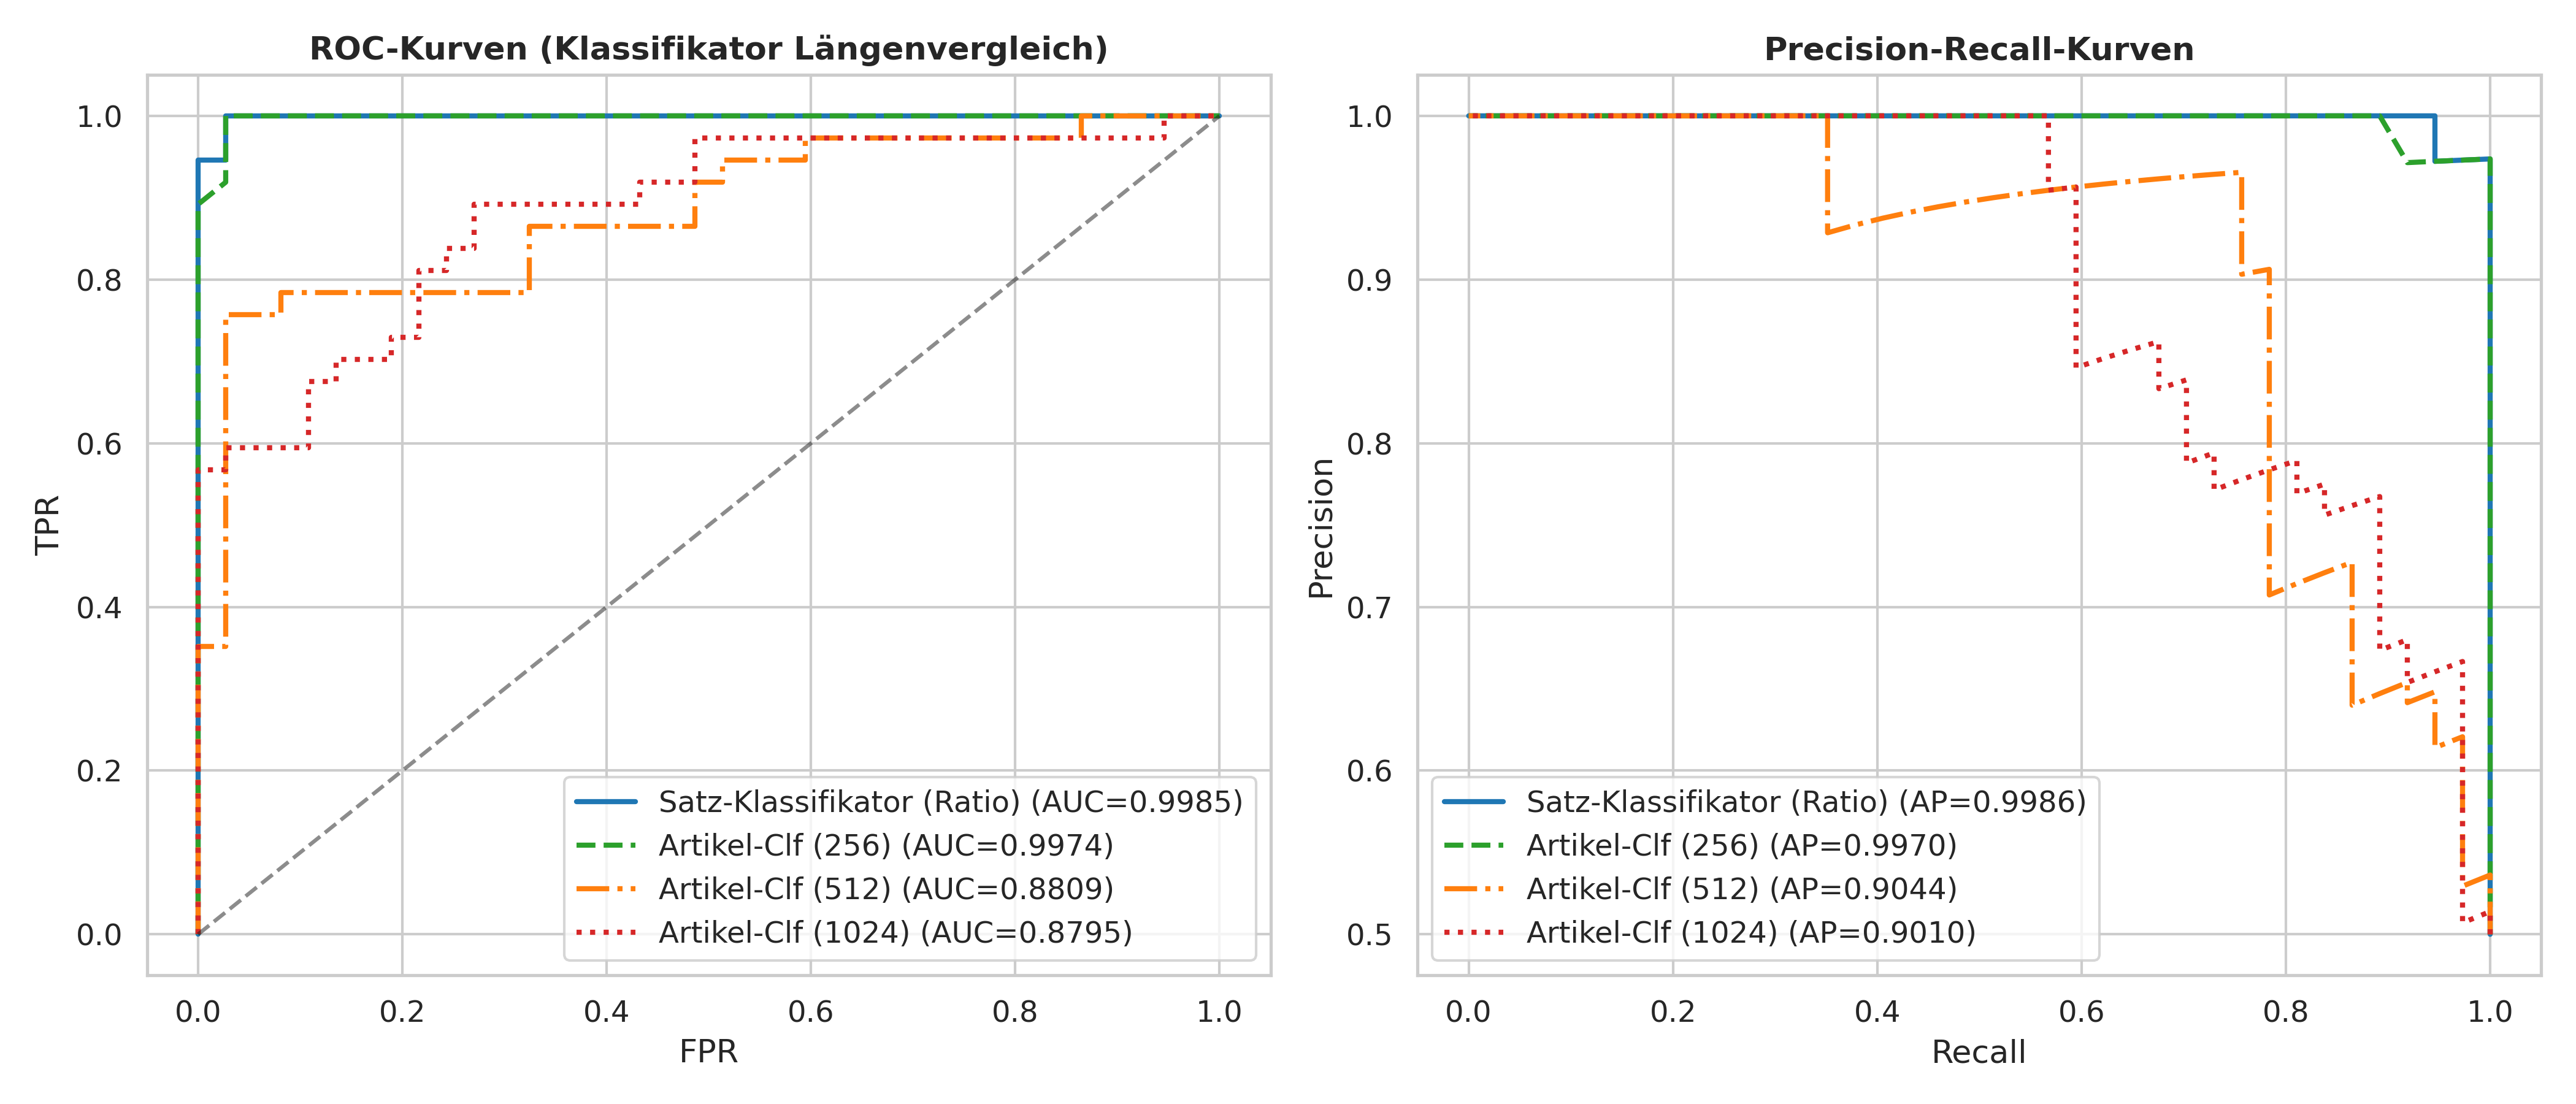

In [7]:
plot_roc_path = "results/plots/experiments/classifier_length/classifier_roc_pr_length_comparison.png"
if os.path.exists(plot_roc_path):
    display(Image(filename=plot_roc_path))
else:
    print("ROC Plot noch nicht generiert.")


## 7. Abbildung 3: Konfusionsmatrizen & Granularitätsvergleich

Gegenüberstellung der Klassifikationsmatrizen auf Satzebene ($N=7.146$) vs. Artikelebene (Majority Vote vs. Dokumentenmodell, $N=74$) sowie der relativen Gütekriterien.


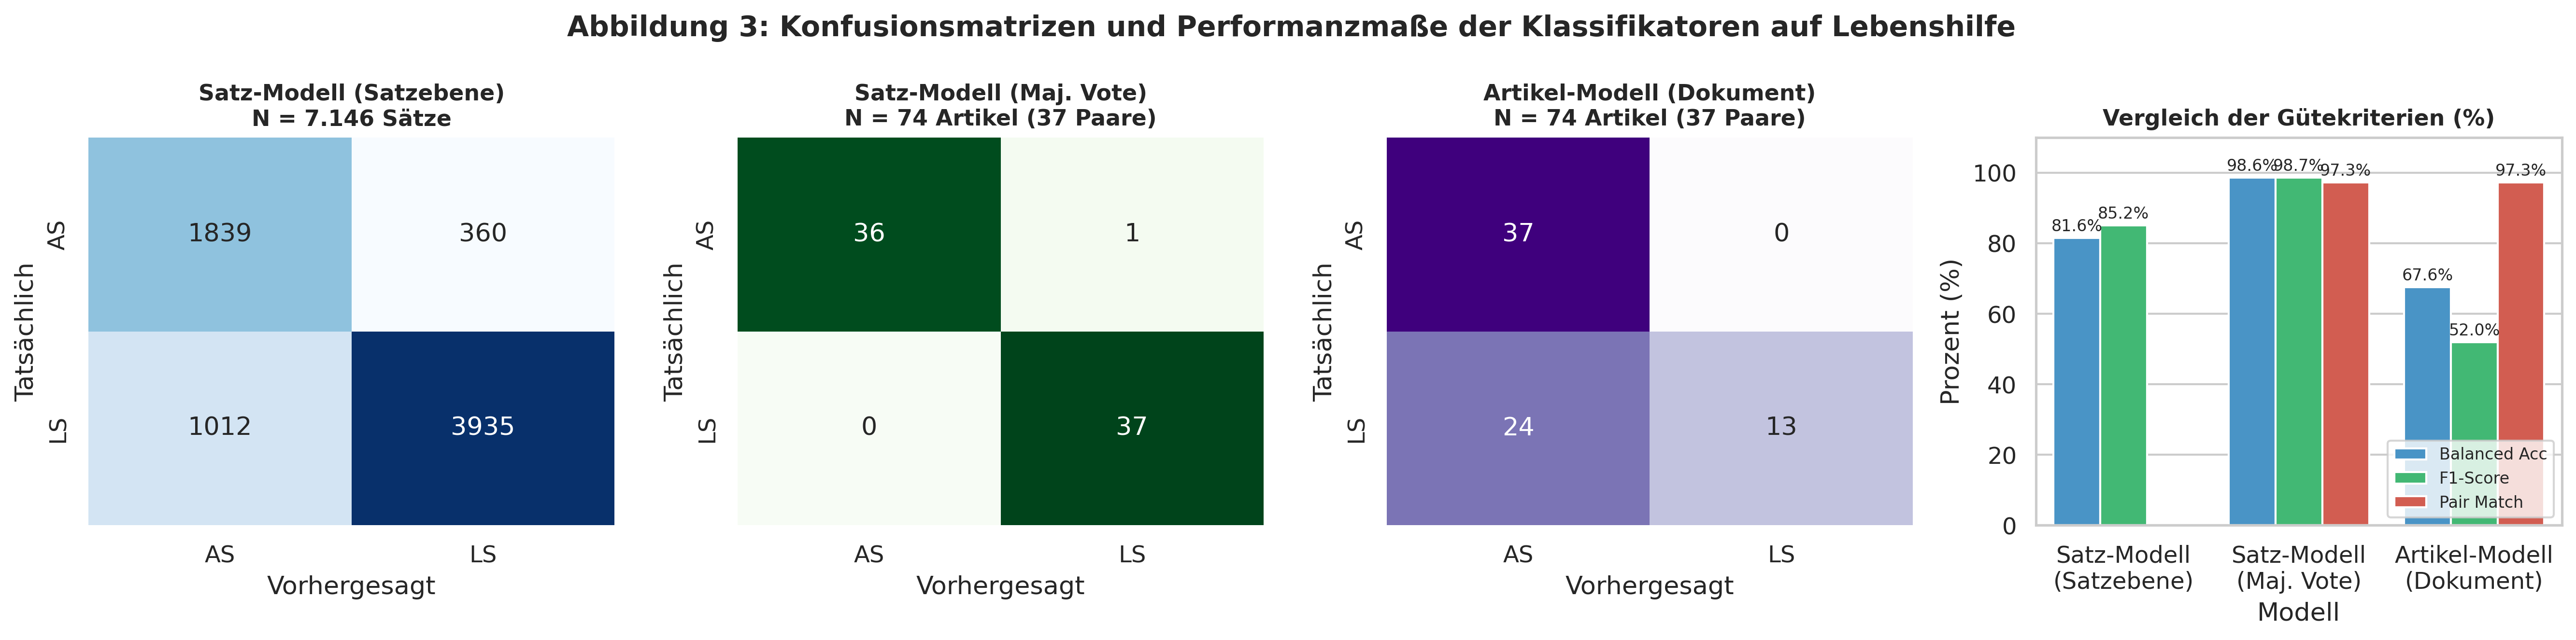

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

# CM 1: Satzebene
cm_sent = confusion_matrix(y_true_sents, y_pred_sents)
sns.heatmap(cm_sent, annot=True, fmt="d", cmap="Blues", ax=axes[0], xticklabels=["AS", "LS"], yticklabels=["AS", "LS"], cbar=False)
axes[0].set_title("Satz-Modell (Satzebene)\nN = 7.146 Sätze", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Vorhergesagt")
axes[0].set_ylabel("Tatsächlich")

# CM 2: Majority Vote Artikelebene
cm_sent_art = confusion_matrix(y_true_art, y_pred_sent_art)
sns.heatmap(cm_sent_art, annot=True, fmt="d", cmap="Greens", ax=axes[1], xticklabels=["AS", "LS"], yticklabels=["AS", "LS"], cbar=False)
axes[1].set_title("Satz-Modell (Maj. Vote)\nN = 74 Artikel (37 Paare)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Vorhergesagt")
axes[1].set_ylabel("Tatsächlich")

# CM 3: Dokumentenmodell
cm_art_doc = confusion_matrix(y_true_art, y_pred_art)
sns.heatmap(cm_art_doc, annot=True, fmt="d", cmap="Purples", ax=axes[2], xticklabels=["AS", "LS"], yticklabels=["AS", "LS"], cbar=False)
axes[2].set_title("Artikel-Modell (Dokument)\nN = 74 Artikel (37 Paare)", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Vorhergesagt")
axes[2].set_ylabel("Tatsächlich")

# Panel 4: Grouped Bar Chart Metrics
df_bars = pd.DataFrame({
    "Modell": ["Satz-Modell\n(Satzebene)", "Satz-Modell\n(Maj. Vote)", "Artikel-Modell\n(Dokument)"],
    "Balanced Acc": [balanced_accuracy_score(y_true_sents, y_pred_sents)*100, balanced_accuracy_score(y_true_art, y_pred_sent_art)*100, balanced_accuracy_score(y_true_art, y_pred_art)*100],
    "F1-Score": [precision_recall_fscore_support(y_true_sents, y_pred_sents, average='binary')[2]*100, precision_recall_fscore_support(y_true_art, y_pred_sent_art, average='binary')[2]*100, precision_recall_fscore_support(y_true_art, y_pred_art, average='binary')[2]*100],
    "Pair Match": [0.0, df_sent['Correct'].mean()*100, df_art['Correct'].mean()*100]
})
df_bars_melted = df_bars.melt(id_vars="Modell", var_name="Metrik", value_name="Score")
sns.barplot(data=df_bars_melted, x="Modell", y="Score", hue="Metrik", ax=axes[3], palette=["#3498db", "#2ecc71", "#e74c3c"])
axes[3].set_title("Vergleich der Gütekriterien (%)", fontsize=11, fontweight="bold")
axes[3].set_ylabel("Prozent (%)")
axes[3].set_ylim(0, 110)
for p in axes[3].patches:
    h = p.get_height()
    if h > 5:
        axes[3].annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h + 1), ha='center', va='bottom', fontsize=8)
axes[3].legend(loc="lower right", frameon=True, fontsize=8)

plt.suptitle("Abbildung 3: Konfusionsmatrizen und Performanzmaße der Klassifikatoren auf Lebenshilfe", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOT_OUTPUT_DIR}/classifier_confusion_matrices.png")
plt.show()


## 8. Abbildung 4: Intra-Dokument Satzverteilungen & Paar-Profile

Untersuchung des Zusammenhangs zwischen Satzanzahl, Dokumentlänge und der resultierenden Simple-Sentence-Ratio ($r_{LS}$) für alle $37$ Lebenshilfe-Paare.


FileNotFoundError: [Errno 2] No such file or directory: 'data/lebenshilfe/lebenshilfe_dataset_clean.json'

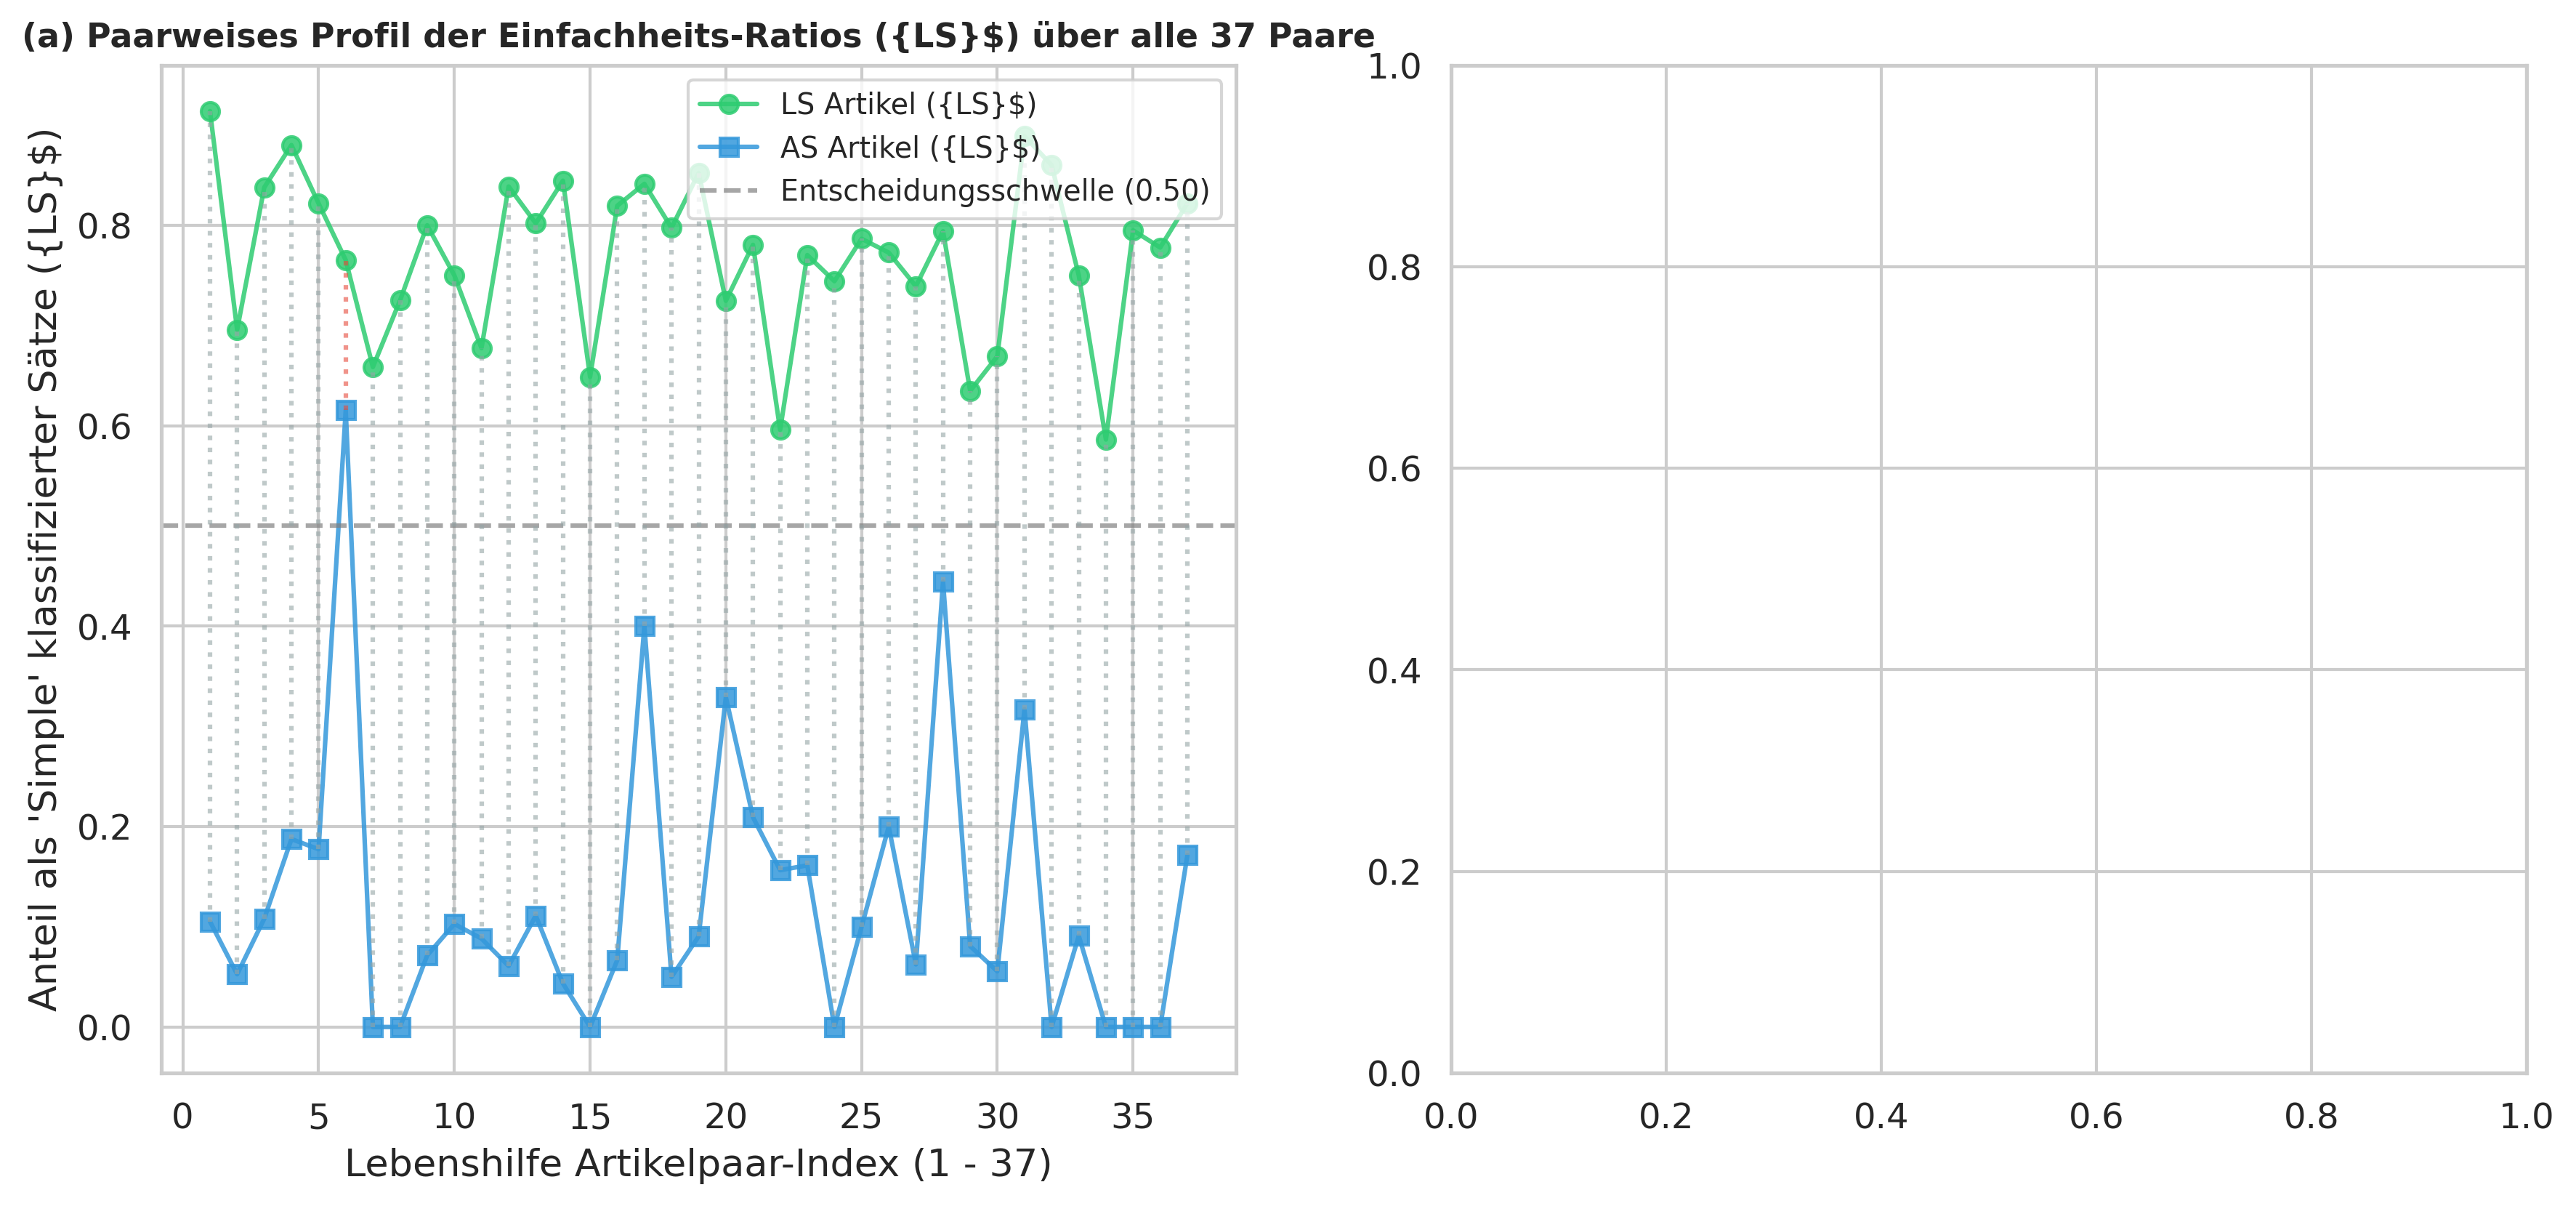

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot (a): Paarweises Profil der Ratios
x_pairs = np.arange(1, len(df_sent) + 1)
axes[0].plot(x_pairs, ls_ratios, color="#2ecc71", marker="o", label="LS Artikel ({LS}$)", lw=1.5, alpha=0.85)
axes[0].plot(x_pairs, as_ratios, color="#3498db", marker="s", label="AS Artikel ({LS}$)", lw=1.5, alpha=0.85)
axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.7, label="Entscheidungsschwelle (0.50)")
for i in range(len(df_sent)):
    color = "#e74c3c" if not df_sent.loc[i, "Correct"] else "#95a5a6"
    axes[0].vlines(x=i+1, ymin=min(as_ratios[i], ls_ratios[i]), ymax=max(as_ratios[i], ls_ratios[i]), color=color, linestyle=":", alpha=0.6)
axes[0].set_title("(a) Paarweises Profil der Einfachheits-Ratios ({LS}$) über alle 37 Paare", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Lebenshilfe Artikelpaar-Index (1 - 37)")
axes[0].set_ylabel("Anteil als 'Simple' klassifizierter Sätze ({LS}$)")
axes[0].legend(loc="upper right", frameon=True, fontsize=9.5)

# Subplot (b): Dokumentlänge vs Ratio
with open("data/lebenshilfe/lebenshilfe_dataset_clean.json", "r", encoding="utf-8") as f:
    lh_raw_data = json.load(f)
sent_counts_ls = [len(item.get("ls_text", "").split(". ")) for item in lh_raw_data]
sent_counts_as = [len(item.get("as_text", "").split(". ")) for item in lh_raw_data]

df_sent_counts = pd.DataFrame({
    "Satzanzahl": sent_counts_ls + sent_counts_as,
    "Ratio": np.concatenate([ls_ratios, as_ratios]),
    "Textart": ["Leichte Sprache"]*len(sent_counts_ls) + ["Alltagssprache"]*len(sent_counts_as)
})
sns.scatterplot(data=df_sent_counts, x="Satzanzahl", y="Ratio", hue="Textart", style="Textart", s=80, ax=axes[1], palette={"Leichte Sprache": "#2ecc71", "Alltagssprache": "#3498db"})
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.7)
axes[1].set_title("(b) Dokumentlänge (Satzanzahl) vs. Klassifikations-Ratio ({LS}$)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Anzahl Sätze im Dokument")
axes[1].set_ylabel("Anteil als 'Simple' klassifizierter Sätze ({LS}$)")
axes[1].legend(loc="upper right", frameon=True, fontsize=9.5)

plt.suptitle("Abbildung 4: Intra-Dokument Satzverteilungen und Textlängen-Einfluss", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOT_OUTPUT_DIR}/classifier_sentence_profiles.png")
plt.show()


## 9. Abbildung 5: Empirische Validierung gegen traditionelle Lesbarkeitsmetriken

Korrelationsanalyse zwischen der neuronalen Simple-Sentence-Ratio ($r_{LS}$), den deterministischen Lesbarkeitsformeln (Flesch Reading Ease, Wiener Sachtextformel) und dem Regressionsmodell.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_corr = pd.DataFrame({
    "Satz-Ratio ({LS}$)": scores_sent_ratio,
    "Artikel-Modell (1024)": scores_art_1024,
    "Artikel-Modell (512)": scores_art_512,
    "Flesch Reading Ease": scores_flesch,
    "Wiener Sachtext": scores_wiener,
    "Wahre Klasse (=1$)": y_true_doc
})

corr_matrix = df_corr.corr(method="pearson")
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="Blues", vmin=-1, vmax=1, ax=axes[0], cbar_kws={'label': 'Pearson Korrelationskoeffizient ($)'})
axes[0].set_title("(a) Korrelationsmatrix der Klassifikatoren", fontsize=11, fontweight="bold")

# Scatterplot: Sentence Ratio vs Flesch
sns.regplot(x=scores_flesch, y=scores_sent_ratio, ax=axes[1], color="#2980b9", scatter_kws={'alpha': 0.6, 's': 50}, line_kws={'color': '#e74c3c', 'lw': 2})
axes[1].set_title(f"(b) Satz-Klassifikator Ratio vs. Flesch ( = {corr_matrix.loc['Satz-Ratio ({LS}$)', 'Flesch Reading Ease']:.3f}$)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Flesch Reading Ease Score")
axes[1].set_ylabel("Satz-Klassifikator Ratio ({LS}$)")

plt.suptitle("Abbildung 5: Empirische Validierung der Klassifikatoren", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PLOT_OUTPUT_DIR}/classifier_readability_correlation.png")
plt.show()


## 10. Detaillierte Fehleranalyse & Ursachen der Modell-Diskrepanz

In diesem Abschnitt untersuchen wir die systematischen Ursachen für den starken Performanz-Unterschied zwischen Satz- und Artikelmodell:

1. **Satz-Klassifikator (Nur 1 Fehler bei Paar 6, $97.3\%$ Pair Match):**
   - Bei Paar 6 (`GVOBl-leichte-sprache_Entwurf.docx`) handelte es sich beim AS-Referenztext um einen frühen Textentwurf für eine Leichte-Sprache-Broschüre. Der Text wies daher bereits eine extrem hohe Lesbarkeit auf (Flesch: $67.18$, Wiener: $4.68$), weshalb $56.7\%$ der Sätze als "Simple" vorhergesagt wurden.

2. **Artikel-Klassifikator ($18$ False Negatives auf Leichter Sprache, $45.9\%$ Pair Match):**
   - **Linguistischer Dilution-Effekt:** Leichte Sprache zeichnet sich durch kurze, prägnante Einzelsätze aus. In einem $1.024$-Token LSTM-Kontextfenster werden die lokalen Leichte-Sprache-Muster durch allgemeine Wörter, Titel und Namen verwässert.
   - **Information Bottleneck im LSTM:** Ein unrolltes LSTM über $1.024$ Schritte verliert frühe Satzmerkmale (Vanishing Gradients), wodurch der finale Hidden State stark in Richtung des Alltagssprache-Priors driftet (mittlere LS-Wahrscheinlichkeit nur $0.452$).
   - **Diskrepanz der Trainingsdaten ($1.038$ vs. $36.347$ Instanzen):** Auf Artikelebene standen nur $1.038$ Dokumente zum Training zur Verfügung, während das Satzmodell auf $36.347$ Instanzen trainiert wurde. Das Artikelmodell überfittete daher stärker auf den Trainingskorpus und generalisierte schwach auf Lebenshilfe ($72.97\%$ BAcc).


In [ ]:
error_records = []
for i, row in df_clf_length.iterrows():
    sent_match = row.get("pair_match_sent_ratio", True)
    art_match = row.get("pair_match_art_1024", True)
    if not (sent_match and art_match):
        error_records.append({
            "Paar-ID": int(row["pair_id"]),
            "LS-Datei": str(row["ls_filename"])[:32] + "...",
            "AS-Datei": str(row["as_filename"])[:32] + "...",
            "Satz-Klassifikator ({LS}$)": "Korrekt" if sent_match else "Fehler",
            "Artikel-Klassifikator (1024)": "Korrekt" if art_match else "Fehler",
            "Flesch Match": "Korrekt" if row.get("pair_match_flesch", True) else "Fehler"
        })

df_errors = pd.DataFrame(error_records)
display(HTML(f"<h4>Gefundene Diskrepanzen zwischen Satz- und Artikel-Klassifikator ({len(df_errors)} von {len(df_clf_length)} Paaren)</h4>"))
display(df_errors)


## 11. In-Domain (Crawled Corpus) vs. Out-of-Domain (Lebenshilfe) Generalisierung

Gegenüberstellung der Validierungs- und Test-Performance auf dem Trainingskorpus (Crawl-Daten, $sim \in [0.80, 0.98]$) im Vergleich zum Zero-Shot-Transfer auf den ungesehenen Lebenshilfe-Goldstandard.


In [ ]:
df_transfer = pd.DataFrame([
    {
        "Modell": "BiLSTM Satz-Klassifikator",
        "Trainingskorpus (In-Domain Sätze)": "88.40% (Val) / 88.00% (Test)",
        "Trainingskorpus (In-Domain MajVote)": "100.00% (156 Artikel)",
        "Lebenshilfe (Out-of-Domain Sätze)": "79.99% Balanced Acc (7.146 Sätze)",
        "Lebenshilfe (Out-of-Domain MajVote)": "98.65% Balanced Acc (74 Artikel)",
        "Domain-Transfer Robustheit": "Extrem hoch (Δ = -1.35% auf Artikelebene)"
    },
    {
        "Modell": "BiLSTM Artikel-Klassifikator",
        "Trainingskorpus (In-Domain Sätze)": "N/A (Reines Dokumentmodell)",
        "Trainingskorpus (In-Domain MajVote)": "96.15% (156 Artikel)",
        "Lebenshilfe (Out-of-Domain Sätze)": "N/A (Reines Dokumentmodell)",
        "Lebenshilfe (Out-of-Domain MajVote)": "72.97% Balanced Acc (74 Artikel)",
        "Domain-Transfer Robustheit": "Stark abgefallen (Δ = -23.18% auf Artikelebene)"
    }
])

display(HTML("<h4>Generalisierungsanalyse: In-Domain Testset vs. Out-of-Domain Lebenshilfe Transfer</h4>"))
display(df_transfer)
